# Лекция.  Регуляризация ближайших соседей

In [2]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning) 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import seaborn as sns
sns.set_style("whitegrid")

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler

from sklearn.preprocessing import PolynomialFeatures


from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsClassifier

from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
from sklearn.linear_model import BayesianRidge

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.metrics import confusion_matrix

Прошлая лекция была посвящена регуляризации линейной регрессии — и, признаемся честно, порог входа там был высок. Чтобы понять, зачем в Ridge мы сдвигаем спектр положительно определённой матрицы, нужно было не просто прочитать определение — нужно было прочувствовать линейную алгебру. Проникнуться ею. Возможно, даже полюбить её.

С регуляризацией ближайших соседей — иное дело. Здесь порог входа почти нулевой. Идеи интуитивно очевидны, прозрачны, можно сказать — самоочевидны. Не нужно ни спектров, ни собственных значений, ни матриц Грама.

Но не обольщайтесь.

То, что входить легко, не означает, что выходить будет просто. Скорее наоборот. Самоочевидность — коварная штука. Она усыпляет бдительность. И когда вы решите, что всё понятно — вот тогда всё и начнётся.

## § 1. Параметр `n_neighbors`

Самый простой и интуитивно понятный способ регуляризовать метод ближайших соседей — это отрегулировать, собственно, их число. Самый простой? — да. И, в общем-то, обязательный. Настолько обязательный, что ниже мы ещё не раз к этому вернёмся.

Дефолтное значение параметра `n_neighbors`, задающего количество соседей, с которыми модель советуется перед тем, как вынести вердикт, — равно пяти. То есть `n_neighbors=5`. Стандарт. Скромно. Консервативно.

Что будет, если эту цифру увеличить? Давайте проверим. Возьмём задачу бинарной классификации и прогоним её через разные значения `n_neighbors`. Посмотрим, кто кого.

### 1.1. Пессимистичный пример

#### Контекст

В производстве керамических плиток имеются две равноправные линейки: «матовая» и «глянцевая». Обе — качественная продукция, обе востребованы, объёмы примерно равны. 

#### Предикторы

- reflection — коэффициент отражения света (float),
- roughness  — шероховатость поверхности (float).

#### Таргет

- type — тип плитки: 0 — матовая, 1 — глянцевая (int).

#### Задача

По двум измерениям определить, к какой линейке относится плитка.

Прочитаем и визуализируем данные:

,reflection,roughness,type
0,15.536094,14.888790,1
1,16.491889,13.314356,1
2,8.392517,10.184634,0
3,15.614011,14.031967,1
4,9.243649,8.577746,0
...,...,...,...
995,7.918071,11.696456,0
996,10.521942,10.296985,0
997,9.962365,11.103302,0
998,12.542515,11.930573,1


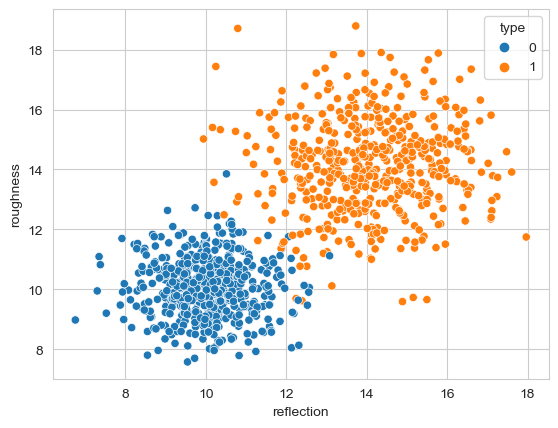

In [47]:
df = pd.read_csv('data/tile.csv')
display(df)
sns.scatterplot(data = df, x='reflection', y='roughness', hue='type')
plt.show()

Перед нами — картинка, которую приятно показать даже людям, далёким от data science. Классы разделены так, что не нужен никакой классификатор — достаточно линейки и хорошего зрения. Но мы, разумеется, классификатор всё равно построим. Из принципа.

#### Baseline-модель

Начнём с базового сценария. Берём `KNeighborsClassifier` с дефолтными параметрами. Формируем левую и правую части задачи, запускаем 100 случайных разбиений на train и test. Поскольку классы сбалансированы — метрикой берём accuracy, без затей.

In [48]:
X = df.drop(columns = ['type'])
y = df['type']

score_train_list = []
score_test_list = []

for seed in range(25):

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=seed)

    model = KNeighborsClassifier()
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    score_train = accuracy_score(y_train, y_train_pred)
    score_test = accuracy_score(y_test, y_test_pred)

    score_train_list.append(score_train)
    score_test_list.append(score_test)
    
accuracy_train = round(np.array(score_train_list).mean(), 4)
accuracy_test = round(np.array(score_test_list).mean(), 4)

print('accuracy_train =', accuracy_train)
print('accuracy_test =', accuracy_test)

accuracy_train = 0.9891
accuracy_test = 0.9864


Замечательно. Впрочем, ничего иного мы и не ожидали — картинка с самого начала не оставляла интриги.

#### Изменение числа ближайших соседей

Теперь попробуем изменить число ближайших соседей. Проведем цикл по параметру `n_neighbors`: пусть число соседей идёт от дефолтного значения `n_neighbors=5` до половины объёма выборки с шагом 25. На каждом шаге — 100 случайных разбиений на train и test, усреднение accuracy, и в результате для каждого n_neighbors получаем пару: скор на обучении и скор на тесте.

Погнали.

-------------------
Индикатор прогресса
-------------------
k = 5
k = 30
k = 55
k = 80
k = 105
k = 130
k = 155
k = 180
k = 205
k = 230
k = 255
k = 280
k = 305
k = 330
k = 355
k = 380
k = 405
k = 430
k = 455
k = 480
-------------------



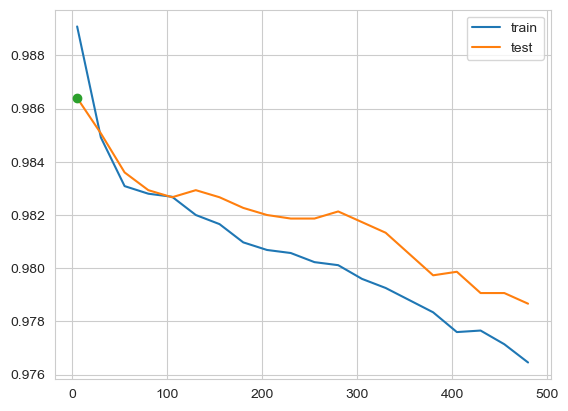

In [49]:
X = df.drop(columns = ['type'])
y = df['type']

horisontal_ax = []
Accuracy_train_list = []
Accuracy_test_list = []

print('-------------------')
print('Индикатор прогресса')
print('-------------------')

for k in range(5, round(50*len(X)/100), 25):


    print('k =', k)
    horisontal_ax.append(k)

    accuracy_train_list = []
    accuracy_test_list = []

    for seed in range(25):

        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=seed)

        model = KNeighborsClassifier(k)
        model.fit(X_train, y_train)

        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)

        accuracy_train = accuracy_score(y_train, y_train_pred)
        accuracy_test = accuracy_score(y_test, y_test_pred)

        accuracy_train_list.append(accuracy_train)
        accuracy_test_list.append(accuracy_test)

    Accuracy_train_list.append(np.array(accuracy_train_list).mean())
    Accuracy_test_list.append(np.array(accuracy_test_list).mean())
    
print('-------------------')
print('')
plt.plot(horisontal_ax, Accuracy_train_list, label = 'train')
plt.plot(horisontal_ax, Accuracy_test_list, label = 'test')
plt.plot(horisontal_ax[0], Accuracy_test_list[0], 'o')
plt.legend()
plt.show()

И вот тут — позвольте небольшой риторический вопрос. А зачем, собственно, мы так мучились? Дефолтное `n_neighbors=5` справилось блестяще, а все попытки улучшить результат привели ровно к противоположному.

### 1.2. Еще один пессимистичный пример

Возьмем другие данные. Тоже из области производства, на этот раз — металлургического.

In [50]:
df = pd.read_csv('data/metal.csv')
df

,carbon_pct,manganese_pct,silicon_pct,sulfur_pct,phosphorus_pct,chromium_pct,nickel_pct,copper_pct,aluminum_pct,vanadium_pct,...,length_mm,temp_finish_rolling,temp_coiling,cooling_rate,tension_rolling,rolling_speed,elongation_pct,impact_strength_m40,yield_ratio,category
0,0.239705,0.202692,0.335947,0.007354,0.011625,-0.015151,0.034040,0.039825,0.042912,-0.004543,...,11123.637762,799.687163,578.737531,26.528643,26.764683,5.753519,18.212057,77.742237,0.715578,1
1,0.186847,1.136255,0.252721,0.015648,0.013660,0.111192,0.025215,0.015033,0.019995,0.019765,...,11272.258403,854.405896,638.033893,36.575280,33.311833,6.505862,28.413570,81.864543,0.716785,1
2,0.188297,0.914128,0.291510,0.011353,0.003447,0.122565,0.014973,0.011858,0.059439,0.009908,...,8652.204143,845.160618,628.529553,31.431585,16.416531,3.301266,22.379195,72.074793,0.727252,1
3,0.156488,1.055984,0.368557,0.009781,0.016166,0.162336,0.076119,0.019480,0.068086,0.005591,...,11657.234651,838.702334,563.843957,38.734102,22.746904,7.014372,23.526045,70.253183,0.600036,1
4,0.210759,1.038770,0.245114,0.007906,0.011508,0.085846,0.050128,0.010927,0.043558,-0.000133,...,10940.739775,869.394939,600.136570,41.111440,27.147025,9.640601,15.501607,57.191503,0.833878,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,0.161988,0.682743,0.226461,0.005880,0.023689,-0.036098,0.029234,0.027590,0.051258,0.012610,...,12821.390628,839.275215,510.305231,17.452111,24.298133,6.955740,14.179599,47.262108,0.707360,0
996,0.186954,1.113733,0.239429,0.015163,0.010188,-0.023060,0.000467,0.034956,0.032660,0.019351,...,11287.575100,846.725842,571.310027,32.914289,20.359341,5.660498,18.034580,62.077519,0.702616,0
997,0.169376,1.019220,0.211936,0.014974,0.007871,0.203252,0.035919,0.026054,0.037007,0.012107,...,9574.569848,818.023777,637.867447,18.148191,19.382904,6.641546,33.615347,85.193465,0.749081,1
998,0.172609,1.555615,0.305669,0.007548,0.010369,0.097637,0.033009,0.005801,0.043588,0.003958,...,13638.842414,870.940048,589.678216,16.107501,29.829158,5.083739,15.250094,49.979458,0.609822,0


#### Контекст

На металлургическом комбинате производится горячекатаный листовой прокат. После прокатки каждый лист проходит через систему автоматизированного контроля качества, которая измеряет 60+ параметров: химический состав, механические свойства, результаты ультразвукового контроля в нескольких точках, геометрические размеры и технологические параметры прокатки.

Готовые листы сортируются на две небракованные категории:

- Категория A — для ответственных сварных конструкций (требуется повышенная ударная вязкость)
- Категория B — для общестроительных металлоконструкций

По статистике производства, категории A и B выпускаются в соотношении примерно 50/50 (это зависит от заказов клиентов, но в целом — поровну). Брак отбраковывается автоматически и в данную выборку не попадает.

#### Предикторы (все float)

- impact_strength_m40 — ударная вязкость KCU при -40°C, Дж/см²,
- yield_ratio — отношение предела текучести к временному сопротивлению,
- carbon_pct — массовая доля углерода, %,
- manganese_pct — массовая доля марганца, %,
- silicon_pct — массовая доля кремния, %,
- sulfur_pct — массовая доля серы, %,
- phosphorus_pct — массовая доля фосфора, %,
- chromium_pct — массовая доля хрома, %,
- nickel_pct — массовая доля никеля, %,
- copper_pct — массовая доля меди, %,
- aluminum_pct — массовая доля алюминия, %,
- vanadium_pct — массовая доля ванадия, %,
- titanium_pct — массовая доля титана, %,
- niobium_pct — массовая доля ниобия, %,
- nitrogen_pct — массовая доля азота, %,
- uct_amplitude1 — амплитуда сигнала УЗК, точка 1, %,
- uct_amplitude2 — амплитуда сигнала УЗК, точка 2, %,
- uct_amplitude3 — амплитуда сигнала УЗК, точка 3, %,
- uct_defect_depth1 — глубина залегания дефекта, точка 1, мм,
- uct_defect_depth2 — глубина залегания дефекта, точка 2, мм,
- uct_defect_depth3 — глубина залегания дефекта, точка 3, мм,
- thickness_mm — толщина листа, мм,
- width_mm — ширина листа, мм,
- length_mm — длина листа, мм,
- temp_finish_rolling — температура конца прокатки, °C,
- temp_coiling — температура смотки в рулон, °C,
- cooling_rate — скорость охлаждения, °C/с,
- tension_rolling — усилие прокатки, МН,
- rolling_speed — скорость прокатки, м/с,
- elongation_pct — относительное удлинение, %.

#### Таргет

- category — категория листа (1 — A, 0 — B)	(int).

#### Бизнес-задача

Построить модель, которая по набору измеренных параметров определит категорию листа.

Начнем с baseline-модели — своего рода точки отсчета, относительно которой мы будем оценивать все последующие улучшения. Признаться, я никогда не жду от baseline чудес, но и не отношусь к нему с пренебрежением: это необходимый диагностический шаг. Позволим же модели проявить себя в первозданном виде, без какого-либо тюнинга.


#### Baseline-модель

Сначала решим задачу с дефолтными параметрами. Формируем левую и правую части задачи классификации и производим 100 запусков со случайными разбиениями на train и test. Классы сбалансированы, в качестве метрики эффективности снова используем просто accuracy.

In [51]:
X = df.drop(columns = ['category'])
y = df['category']

score_train_list = []
score_test_list = []

for seed in range(25):

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=seed)

    model = KNeighborsClassifier()
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    score_train = accuracy_score(y_train, y_train_pred)
    score_test = accuracy_score(y_test, y_test_pred)

    score_train_list.append(score_train)
    score_test_list.append(score_test)
    
accuracy_train = round(np.array(score_train_list).mean(), 4)
accuracy_test = round(np.array(score_test_list).mean(), 4)

print('accuracy_train =', accuracy_train)
print('accuracy_test =', accuracy_test)

accuracy_train = 0.6899
accuracy_test = 0.5012


Ну… прямо скажем, так себе. Скор на test'е прямо говорит, что это просто случайное угадывание. Впрочем, ровно этого и следовало ожидать: пять соседей по умолчанию и евклидова метрика в тридцатимерном пространстве — не лучший рецепт для успеха. Но не будем задерживаться на этом результате дольше необходимого. Baseline свое дело сделал — показал, что задача без дополнительных усилий не решается, и нам предстоит интересная работа.

#### Изменение числа ближайших соседей

Попробуем прогнать задачу через разные значения `n_neighbors`. Снова делаем такой же цикл, как и в предыдущем примере.

-------------------
Индикатор прогресса
-------------------
k = 5
k = 30
k = 55
k = 80
k = 105
k = 130
k = 155
k = 180
k = 205
k = 230
k = 255
k = 280
k = 305
k = 330
k = 355
k = 380
k = 405
k = 430
k = 455
k = 480
-------------------


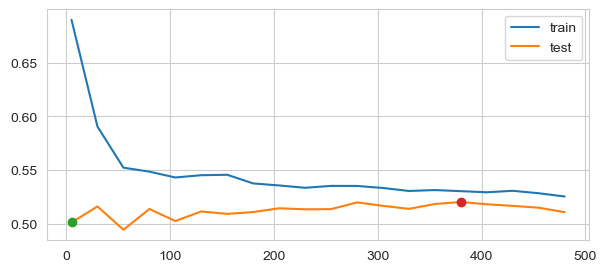

Дефолтный скор: 0.5012
Максимальный скор: 0.5203 при k = 380
Прирост скора: 0.0191


In [52]:
X = df.drop(columns = ['category'])
y = df['category']

horisontal_ax = []

Accuracy_train_list = []
Accuracy_test_list = []

print('-------------------')
print('Индикатор прогресса')
print('-------------------')

for k in range(5, round(50*len(X)/100), 25):
    

    print('k =', k)
    horisontal_ax.append(k)

    accuracy_train_list = []
    accuracy_test_list = []

    for seed in range(25):

        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=seed)

        model = KNeighborsClassifier(k)
        model.fit(X_train, y_train)

        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)

        accuracy_train = accuracy_score(y_train, y_train_pred)
        accuracy_test = accuracy_score(y_test, y_test_pred)

        accuracy_train_list.append(accuracy_train)
        accuracy_test_list.append(accuracy_test)

    Accuracy_train_list.append(np.array(accuracy_train_list).mean())
    Accuracy_test_list.append(np.array(accuracy_test_list).mean())
    
print('-------------------')

max_score_index = np.argmax(np.array(Accuracy_test_list))

plt.figure(figsize=(7, 3))
plt.grid(True)
plt.plot(horisontal_ax, Accuracy_train_list, label = 'train')
plt.plot(horisontal_ax, Accuracy_test_list, label = 'test')
plt.plot(horisontal_ax[0], Accuracy_test_list[0], 'o')
plt.plot(horisontal_ax[max_score_index], Accuracy_test_list[max_score_index], 'o')
plt.legend()
plt.show()

print('Дефолтный скор:', round(np.array(Accuracy_test_list)[0], 4))
print('Максимальный скор:', round(np.array(Accuracy_test_list).max(), 4), 'при k =', max_score_index*25 + 5)
print('Прирост скора:', (np.array(Accuracy_test_list).max() - np.array(Accuracy_test_list)[0]).round(4))

Да… датасайнс — благороднейшее из занятий. И знаете почему? Потому что учит человека смирению.

Вообще-то мы ожидали увидеть несколько иное. А что мы видим? — что даже в лучшем случае модель едва отрывается от случайного угадывания. Параметр `n_neighbors`, судя по всему, не особенно меняет картину.

Однако не будем торопиться с выводами. Давайте сначала порассуждаем о пространствах высокой размерности. Мы узнаем много интересного и… как бы это помягче сказать… не вполне очевидного.

### 1.3. Проклятие размерности

Вы знаете, что происходит с расстояниями в пространствах высокой размерности? Нет? Ну конечно не знаете. Сейчас я вам расскажу — а вы уж постарайтесь сделать вид, что это увлекательно.

Начнем с очевидного. Что такое отрезок? Правильно — это куб, у которого одна сторона. Да-да, я считаю, что это шутка. Не самая удачная, согласен, но уж какая есть. А квадрат? Совершенно верно — куб, у которого две стороны. И это, если вы не поняли, тоже шутка. А какого она качества — не ваше дело. Хотя, если честно, какая там шутка — это чистая правда. В терминах теории множеств все именно так и есть: эти фигуры — родственники, и родственники ближайшие. А их старшие братья в пространствах побольше так и называются: кубы. Четырехмерный куб, пятимерный куб, и так далее, до бесконечности и даже дальше.

И у всех у них есть большая диагональ. Длина ее вычисляется по теореме Пифагора — той самой, которую вы когда-то учили и, возможно, уже успели забыть. Для квадрата все просто: √(1² + 1²) = √2. Для отрезка — еще проще: √(1²) = 1. Для трехмерного куба — √(1² + 1² + 1²) = √3. Для простоты мы считаем, что длина стороны всегда равна единице. Ну и так далее. В пространстве размерности n длина большой диагонали — это √n.

Это понятно любому школьнику. Вот честно — любому. Даже тому, который на уроках геометрии рисовал в тетради ~~карикатуры на учительницу геометрии~~ кораблики.

А теперь — внимание, эксперимент. Будем повышать размерность и каждый раз добавлять в n-мерный куб 500 случайных точек. А в получившемся облаке будем рассчитывать все попарные расстояния (их, между прочим, получится очень много — около 125 тысяч, если кто-то любит точные цифры). Результаты — визуализируем:

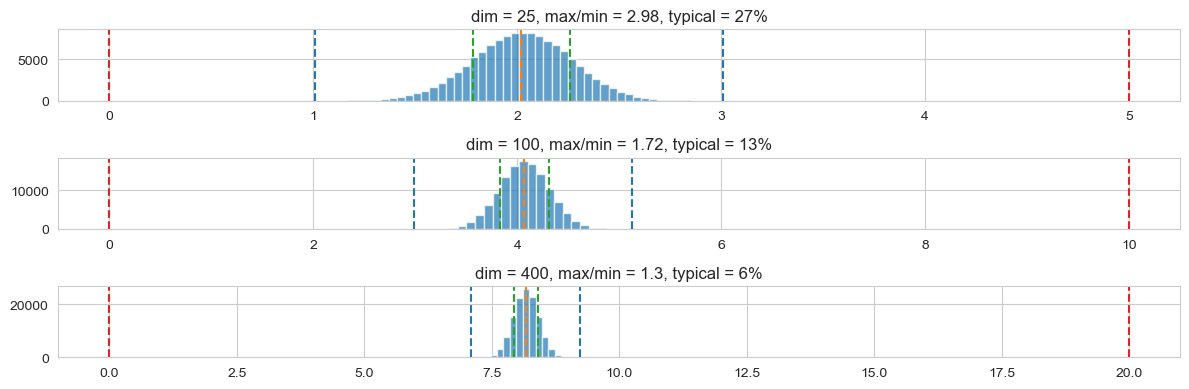

In [53]:
N = 500
k = 21

dim_list = [5, 10, 20]

fig, ax = plt.subplots(nrows=len(dim_list), ncols=1, figsize=(12, len(dim_list) + 1), sharex=False, sharey=False)

a = 0

for d in dim_list:
    
    dim = d**2
    points = np.random.rand(N, dim)
    distances = []

    for i in range(N):
        for j in range(i+1, N):
            dist = np.sqrt(np.sum((points[i] - points[j])**2))
            distances.append(dist)
            
    distances_mean = np.array(distances).mean()
    distances_min = np.array(distances).min()
    distances_max = np.array(distances).max()
    distances_std = np.array(distances).std()
    min_max = round(distances_max/distances_min, 2)
    var = round((distances_mean + distances_std) / (distances_mean - distances_std), 2)
    ax[a].set_title('dim = '+str(d**2)+ ', max/min = '+ str(min_max) + ', typical = '+ str(round((var - 1)*100)) + '%')
    ax[a].hist(distances, bins=int(round(50/(a+1))), alpha=0.7)
    ax[a].axvline(x=distances_mean, color='C1', linestyle='--')
    ax[a].axvline(x=distances_mean - distances_std, color='C2', linestyle='--')
    ax[a].axvline(x=distances_mean + distances_std, color='C2', linestyle='--')
    ax[a].axvline(x=distances_min, color='C0', linestyle='--')
    ax[a].axvline(x=distances_max, color='C0', linestyle='--')
    ax[a].axvline(x=0, color='C3', linestyle='--')
    ax[a].axvline(x=d, color='C3', linestyle='--')
    
    a = a + 1
    
plt.tight_layout()
plt.show()

И вот здесь мы приходим к результатам, которые, мягко говоря, удивляют. В пространствах высокой размерности все точки находятся на примерно одинаковом расстоянии друг от друга. Само по себе это уже странно (и именно этот эффект мы, заметьте, будем использовать в дальнейшем), но есть и дополнение: все они еще и лежат примерно на гиперсфере. Ну… плюс-минус немного. Потому что начало координат — не исключение, и оно тоже равноудалено от всех остальных точек.

Представить это невозможно. Даже не пытайтесь. Это не тот случай, когда воображение поможет. Но таковы факты.

Теперь — какое это имеет отношение к нашей задаче. А самое непосредственное. Давайте на минутку предположим, что среди тридцати предикторов лишь очень немногие действительно несут полезный сигнал (например, только один предиктор сигнальный или максимум — два), а подавляющее большинство предикторов — это просто случайный шум по отношению к классу объекта.

Поскольку все расстояния в пространстве высокой размерности — примерно равны между собой, ранжирование по удаленности — это примерно случайный выбор. И если мы отбираем 5 случайных (обратите внимание: мы не говорим — ближайших, мы честно говорим — случайных) объектов, то вероятность того, что большинство из них принадлежит верному классу гораздо ниже, чем если бы мы отбирали 200 случайных объектов. Это не магия, это статистика.

### 1.4. Оптимистичный пример

Учитывая сказанное выше, мы понимаем: если привести все данные к единому масштабу, эффект равноудаленности точек друг от друга в пространстве высокой размерности усилится.

А мы умеем это делать. Мы же проходили нормализацию данных когда-то. Не так давно, кстати. Осталось только вспомнить, как это делается. Сейчас… минутку… А, вот: вызываем `StandardScaler()` и нормализуем левую часть.

-------------------
Индикатор прогресса
-------------------
k = 5
k = 30
k = 55
k = 80
k = 105
k = 130
k = 155
k = 180
k = 205
k = 230
k = 255
k = 280
k = 305
k = 330
k = 355
k = 380
k = 405
k = 430
k = 455
k = 480
-------------------


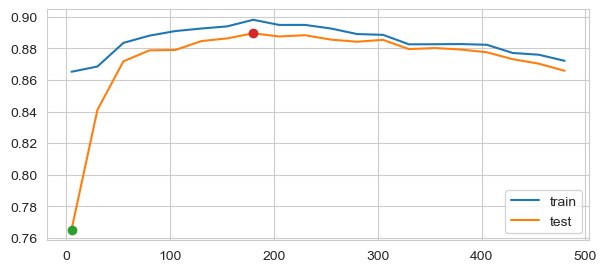

Дефолтный скор: 0.7652
Максимальный скор: 0.8896 при k = 180
Прирост скора: 0.1244


In [54]:
X = df.drop(columns = ['category'])
y = df['category']

scaler = StandardScaler()
X = scaler.fit_transform(X)

horisontal_ax = []

Accuracy_train_list = []
Accuracy_test_list = []

print('-------------------')
print('Индикатор прогресса')
print('-------------------')

for k in range(5, round(50*len(X)/100), 25):
    

    print('k =', k)
    horisontal_ax.append(k)

    accuracy_train_list = []
    accuracy_test_list = []

    for seed in range(25):

        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=seed)

        model = KNeighborsClassifier(k)
        model.fit(X_train, y_train)

        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)

        accuracy_train = accuracy_score(y_train, y_train_pred)
        accuracy_test = accuracy_score(y_test, y_test_pred)

        accuracy_train_list.append(accuracy_train)
        accuracy_test_list.append(accuracy_test)

    Accuracy_train_list.append(np.array(accuracy_train_list).mean())
    Accuracy_test_list.append(np.array(accuracy_test_list).mean())
    
print('-------------------')

max_score_index = np.argmax(np.array(Accuracy_test_list))

plt.figure(figsize=(7, 3))
plt.grid(True)
plt.plot(horisontal_ax, Accuracy_train_list, label = 'train')
plt.plot(horisontal_ax, Accuracy_test_list, label = 'test')
plt.plot(horisontal_ax[0], Accuracy_test_list[0], 'o')
plt.plot(horisontal_ax[max_score_index], Accuracy_test_list[max_score_index], 'o')
plt.legend()
plt.show()

print('Дефолтный скор:', round(np.array(Accuracy_test_list)[0], 4))
print('Максимальный скор:', round(np.array(Accuracy_test_list).max(), 4), 'при k =', max_score_index*25 + 5)
print('Прирост скора:', (np.array(Accuracy_test_list).max() - np.array(Accuracy_test_list)[0]).round(4))

И вот теперь — оптимизм восторжествовал. Мы подняли скор до 0.89. А если вспомнить, с чего мы начинали — с baseline-модели, которая угадывала класс с вероятностью подбрасывания монетки, на уровне 0.5, — то мы, без ложной скромности, молодцы.

### 1.5. Полемический пример

Ну что ж, мы удостоверились, что подбор числа ближайших соседей при определенных обстоятельствах бывает совсем не лишним. Но теперь мы поспорим сами с собой. Вступим, так сказать, в научную полемику.

Давайте проведем предварительное исследование предикторов и посмотрим, как они влияют на принадлежность к классу (и влияют ли вообще). Для этого построим ящик с усами и с разделением по категориям:

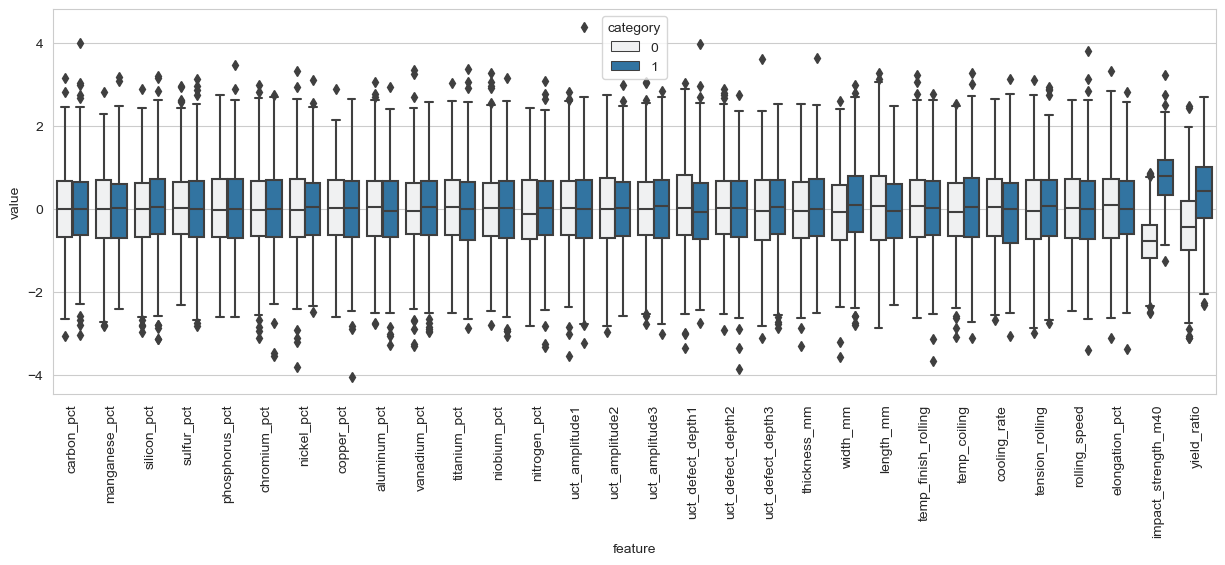

In [55]:
feature_long = pd.DataFrame(columns = ['feature', 'value', 'category'])
for col in df.columns[:-1]:
    d = pd.DataFrame(columns = ['feature', 'value', 'category'])
    d['feature'] = [col]*len(df)
    d['value'] = (df[col] - df[col].mean())/df[col].std()
    d['category'] = df['category']
    feature_long = pd.concat([feature_long, d], ignore_index=True)


plt.figure(figsize=(15, 5))
sns.boxplot(data=feature_long, x='feature', y='value', hue='category', color = 'C0')
plt.xticks(rotation=90)
plt.show()

И что мы видим? Что подавляющее большинство признаков — это действительно шумовые признаки. Сигнал несут только два признака: `impact_strength_m40` и `yield_ratio`. И ситуация ничем не отличается от той, которую мы рассматривали в разделе 1.1. Я бы сказал, один в один. Прямо дежавю какое-то.

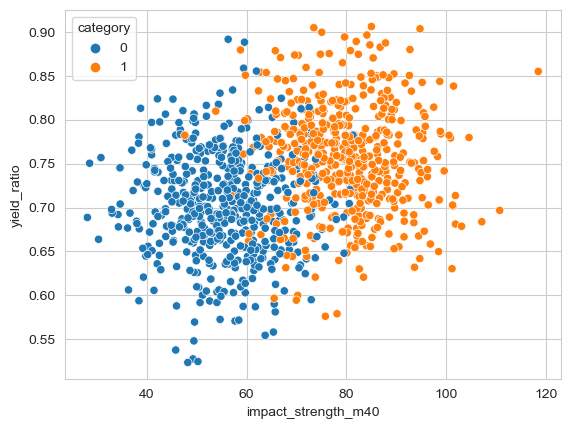

In [56]:
sns.scatterplot(data = df, x='impact_strength_m40', y='yield_ratio', hue='category')
plt.show()

Поэтому мы принимаем волевое решение: выкидываем всё, кроме двух сигнальных признаков, и решаем задачу по дефолту — без этих вот ваших подборов `n_neighbors`. Сказано — сделано:

In [57]:
X = df[['impact_strength_m40', 'yield_ratio']]
y = df['category']

score_train_list = []
score_test_list = []

for seed in range(25):

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=seed)

    model = KNeighborsClassifier()
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    score_train = accuracy_score(y_train, y_train_pred)
    score_test = accuracy_score(y_test, y_test_pred)

    score_train_list.append(score_train)
    score_test_list.append(score_test)
    
accuracy_train = round(np.array(score_train_list).mean(), 4)
accuracy_test = round(np.array(score_test_list).mean(), 4)

print('accuracy_train =', accuracy_train)
print('accuracy_test =', accuracy_test)

accuracy_train = 0.9186
accuracy_test = 0.8809


И вот он, вполне себе прекрасный результат. Казалось бы — регуляризация не нужна, можно обойтись и без нее. 

Но это только кажется. И вот сейчас я вынужден вас немного огорчить — точнее, вывести из этого уютного заблуждения. Дело в том, что мы находимся, если угодно, в тепличных условиях. А теплица, как известно, — это не настоящее поле боя. Это, если хотите, оранжерея, где всё полито, прополото и подписано табличками. Давайте посмотрим правде в глаза и перечислим эти тепличные условия — их, как выясняется, целых три.

#### Первое 

Мы можем решать задачу **неограниченно долго**. Сидим, подбираем n_neighbors, гоняем циклы по сто раз, смотрим на графики, пьём кофе, снова гоняем… У нас есть роскошь времени. А теперь представьте, что классификацию нужно выполнить за доли секунды. Не «когда-нибудь», не «пусть посчитает за ночь» — а именно что за доли секунды, в реальном времени, в потоке, между двумя операциями технологического процесса. Вы почувствовали разницу? То-то же.

#### Второе 

Мы решаем задачу ровно **один раз**. Один датасет, одна модель, один ответ. И даже если мы что-то сделаем не оптимально — никто не заметит, мир не рухнет, завод не остановится. Но в реальных проектах таких задач — тысячи. И каждый раз вручную анализировать предикторы, строить ящики с усами, любоваться scatter plot'ами — простите, но это даже не смешно. Это — роскошь, которую реальный мир не позволяет.

#### И третье 

Число предикторов у нас — 30, **всего-навсего тридцать**. Вот они, все перед глазами — можно разложить на столе, как карточный пасьянс, и рассматривать их сколько угодно. А что будет, когда предикторов станет триста? А три тысячи? А когда среди них будут не только проценты и миллиметры, а какие-нибудь категориальные переменные, текст, время, чёрт знает что ещё? Попробуйте охватить взглядом три тысячи переменных. Нет, вы не сможете. Это уже не «ящик с усами», это — лес, в котором нет ни одной тропинки.

#### А что будет, если...

А если нужно проводить классификацию за доли секунды? Тысячи раз подряд? С тысячами шумовых предикторов? Вы только вслушайтесь в эти цифры — тысячи раз, тысячи предикторов, доли секунды. Вот теперь вы начинаете понимать, что такое настоящая задача. В реальных, а не учебных проектах мы не сможем обойтись без регуляризации. Она не просто желательна — она обязательна, иначе мы утонем в этом океане шума.


И вот здесь-то и вступает в игру подбор числа ближайших соседей для нейтрализации шумовых предикторов в пространствах высокой размерности. Почему он хорош? Потому что это надёжный, проверенный метод. Он рабочий — мы уже убедились в этом на наших примерах. И что самое главное — он полностью исключает человеческий фактор. Не нужно ничего анализировать вручную, не нужно строить десятки графиков, не нужно принимать волевые решения «оставить два признака, а остальные выбросить». Код сам найдёт оптимальное значение `n_neighbors` — и сделает это быстро, чётко и без вашего участия. 

### 1.6. Продолжение полемического примера или еще один  оптимистичный пример

А что, если нам скомбинировать методы? Я имею в виду — не удовлетвориться чем-то одним, а взять и объединить. Давайте посмотрим, что будет, если мы подберем число ближайших соседей на данных, очищенных от шума, и еще вдобавок проведем нормализацию. Сначала уберем шумовые признаки, потом отмасштабируем, а потом уже будем варьировать `n_neighbors`. 

Погнали.

-------------------
Индикатор прогресса
-------------------
k = 5
k = 30
k = 55
k = 80
k = 105
k = 130
k = 155
k = 180
k = 205
k = 230
k = 255
k = 280
k = 305
k = 330
k = 355
k = 380
k = 405
k = 430
k = 455
k = 480
-------------------


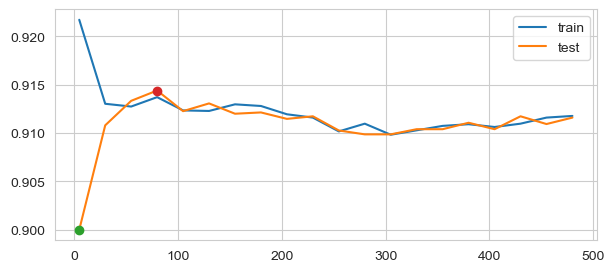

Дефолтный скор: 0.9
Максимальный скор: 0.9144 при k = 80
Прирост скора: 0.0144


In [58]:
X = df[['impact_strength_m40', 'yield_ratio']]
y = df['category']

scaler = StandardScaler()
X = scaler.fit_transform(X)

horisontal_ax = []

Accuracy_train_list = []
Accuracy_test_list = []

print('-------------------')
print('Индикатор прогресса')
print('-------------------')

for k in range(5, round(50*len(X)/100), 25):
    

    print('k =', k)
    horisontal_ax.append(k)

    accuracy_train_list = []
    accuracy_test_list = []

    for seed in range(25):

        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=seed)

        model = KNeighborsClassifier(k)
        model.fit(X_train, y_train)

        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)

        accuracy_train = accuracy_score(y_train, y_train_pred)
        accuracy_test = accuracy_score(y_test, y_test_pred)

        accuracy_train_list.append(accuracy_train)
        accuracy_test_list.append(accuracy_test)

    Accuracy_train_list.append(np.array(accuracy_train_list).mean())
    Accuracy_test_list.append(np.array(accuracy_test_list).mean())
    
print('-------------------')

max_score_index = np.argmax(np.array(Accuracy_test_list))

plt.figure(figsize=(7, 3))
plt.grid(True)
plt.plot(horisontal_ax, Accuracy_train_list, label = 'train')
plt.plot(horisontal_ax, Accuracy_test_list, label = 'test')
plt.plot(horisontal_ax[0], Accuracy_test_list[0], 'o')
plt.plot(horisontal_ax[max_score_index], Accuracy_test_list[max_score_index], 'o')
plt.legend()
plt.show()

print('Дефолтный скор:', round(np.array(Accuracy_test_list)[0], 4))
print('Максимальный скор:', round(np.array(Accuracy_test_list).max(), 4), 'при k =', max_score_index*25 + 5)
print('Прирост скора:', (np.array(Accuracy_test_list).max() - np.array(Accuracy_test_list)[0]).round(4))

Прирост скора, который мы наблюдаем, разумеется, не столь впечатляющ. Какие-то жалкие полтора процента — можно было бы и не заморачиваться, скажете вы. Но я отвечу: нет, нельзя. Потому что суть-то не в величине прироста. И даже не в том, что мы дожали скор до 0.91 — хотя это, согласитесь, приятно. Суть в том, что и на очищенных данных повышение числа ближайших соседей дает эффект. Не иллюзорный, не случайный — а самый настоящий, статистически значимый эффект. И сдвигаемся мы от дефолтного значения `n_neighbors = 5` весьма и весьма далеко: до 80. Вдумайтесь: восемь десятков соседей против пяти. Это уже не «немножко увеличили», это совсем другой режим работы модели.

А это значит, что даже в самой благоприятной ситуации — когда шум удален, когда признаки отобраны вручную, когда всё выглядит идеально — регуляризация через подбор `n_neighbors` всё равно работает. Да, она работает не всегда (мы видели такой пример), но выводы, которые нужно сделать для себя по итогам этого параграфа, просты и категоричны: всегда проверяйте возможные значения `n_neighbors`. И никогда, ни при каких обстоятельствах не доверяйте дефолту. 

## § 2. Параметр `metric`

Второй настраиваемый параметр алгоритма ближайших соседей, который играет заметную роль в процессе регуляризации модели, — это так называемый параметр metric. Если вам показалось, что мы только что произнесли нечто глубокомысленное, — не обольщайтесь: на самом деле мы всего лишь обозначили предмет разговора. Вопрос о том, что именно этот параметр регулирует и почему без него модель рискует превратиться в капризного неврастеника, мы рассмотрим чуть ниже. А пока — договоримся о терминах. Потому что с терминами, как вы уже, вероятно, догадываетесь, всё непросто.


### 2.1. Метрические пространства

Слово «метрика» — одно из тех коварных слов, которые звучат одинаково в разных аудиториях, но означают при этом совершенно разные вещи. То, что называют метрикой в машинном обучении, и то, что называют метрикой в математике, — это, если говорить честно, два разных мира, которые случайно носят одно имя. В машинном обучении под метрикой понимают некоторую меру качества: коэффициент детерминации, accuracy, precision — всё это гордо именуется метриками, хотя по своей природе это не более чем способы измерить, насколько мы не ошиблись. В математике же метрика — это расстояние. Не переносное, не метафорическое, а самое настоящее, аксиоматически выверенное расстояние, со всей его неотрицательностью, симметрией и неравенством треугольника. И если вы сейчас почувствовали лёгкое головокружение от такого соседства понятий — это нормально. Привыкайте: в машинном обучении это чувство будет возникать у вас регулярно


#### Аксиомы метрики

Пусть имеется произвольное множество M. Говорят, что отображение ρ: M × M → R+, сопоставляющее каждой паре элементов некоторое неотрицательное вещественное число ρ(x, y) — которое мы, разумеется, интерпретируем как расстояние, — является метрикой на M, если при этом выполняются следующие четыре аксиомы. Всего четыре. Запомните их — они того стоят.

- Первая: неотрицательность. Формально ρ(x, y) ≥ 0. Смысл её прозрачен до банальности: расстояние не может быть меньше нуля, и на этом, пожалуй, всё. 
- Вторая: аксиома тождества, она же — невырожденность. Она утверждает, что ρ(x, y) = 0 в том и только в том случае, когда x = y. Иными словами, единственный способ оказаться на нулевом расстоянии от чего-либо — это просто быть этим самым чем-либо. Никаких фокусов. 
- Третья: симметрия — ρ(x, y) = ρ(y, x). Расстояние от вас до вашего холодильника ночью в точности равно расстоянию от холодильника до вас, как бы вы ни пытались убедить себя в обратном. 
- И наконец, четвёртая — неравенство треугольника: ρ(x, z) ≤ ρ(x, y) + ρ(y, z). Говоря по-человечески: прямой путь не может быть длиннее, чем путь через дополнительную точку.

Эти четыре аксиомы — не просто формальность. Они задают ровно то, что мы имеем право называть «разумным», математически корректным поведением понятия расстояния. Всё остальное — лишь вариации на эту тему.

#### Евклидова метрика

Начнём с классики — с того самого расстояния, которое вы, сами того не подозревая, вычисляли ещё в школе, когда применяли теорему Пифагора. Евклидова метрика измеряет кратчайшее расстояние между двумя точками так, как это делала бы птица: по прямой, не оглядываясь на земные препятствия. 

Математически это выглядит как корень из суммы квадратов разностей по всем координатам — и если вам показалось, что я только что произнёс что-то сложное, то перечитайте предыдущее предложение ещё раз: по сути, это теорема Пифагора, просто в n-мерном пространстве. 

$$
\rho(x, y) = \sqrt{\sum_{i = 1}^n (x_i - y_i)^2}\,.
$$

Именно эту метрику мы интуитивно считаем «настоящим» расстоянием — и именно её ваша модель будет использовать по умолчанию, если вы не скажете ей обратного.

#### Манхэттенская метрика

Теперь представьте, что вы не птица, а таксист на Манхэттене. Вы не можете лететь по прямой — вы обязаны двигаться по улицам, квартал за кварталом, сворачивая только под прямым углом. Именно это и делает манхэттенская метрика: она суммирует абсолютные разности по каждой координате отдельно, не пытаясь срезать путь по диагонали. Никаких гипотенуз — только катеты, и только вперёд.

$$
\rho(x, y) = \sum_{i = 1}^n |x_i - y_i|\,.
$$

В машинном обучении такая метрика нередко оказывается полезнее евклидовой — особенно когда признаки в ваших данных живут каждый своей жизнью и не любят, когда их перемешивают.

#### Метрика Минковского

Ну и наконец — метрика Минковского. Мой любимый пример того, как математики умеют из двух вещей сделать одну, а потом гордо назвать это обобщением. Метрика Минковского вводит параметр p — и в зависимости от его значения вы получаете либо старую добрую манхэттенскую метрику при p = 1, либо евклидову при p = 2, либо что-то среднее при промежуточных значениях. 

$$
\rho(x, y) = \left(\sum_{i = 1}^n |x_i - y_i|^p\right)^{1/p}\,.
$$

По сути, это способ сказать модели: «Я пока не решил, как именно ты должна измерять расстояние, — так что давай оставим это настраиваемым». И надо признать, модель часто бывает нам за это благодарна.

#### Единичные окружности

Ничто так не проясняет разницу между метриками, как их единичные окружности — то есть множества точек, находящихся на расстоянии ровно единица от начала координат. 

В евклидовом мире это, само собой, обычная окружность — круглая, гладкая, предсказуемая. В манхэттенском мире это ромб — колючий, угловатый, словно сама геометрия города не терпит плавных линий. А в мире Минковского — это целый спектр фигур, плавно перетекающих из ромба в окружность и далее во что-то, напоминающее квадрат со скруглёнными углами, по мере того как параметр p растёт. 

Интернет, разумеется, переполнен этими картинками — и, честно говоря, я не вижу причин лишать вас этого зрелища.

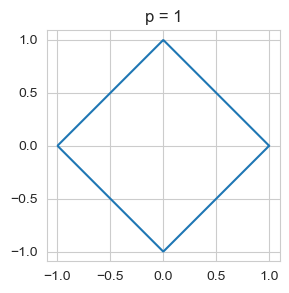

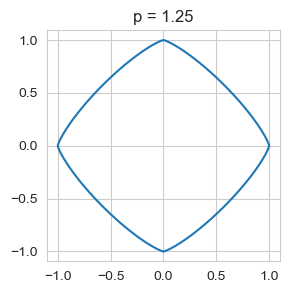

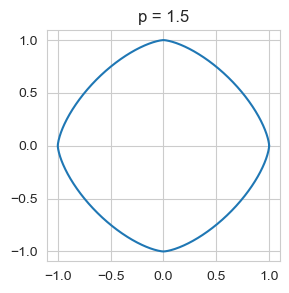

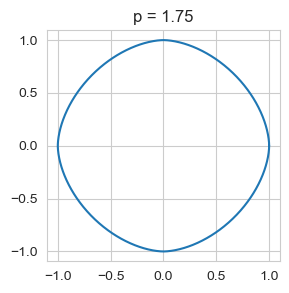

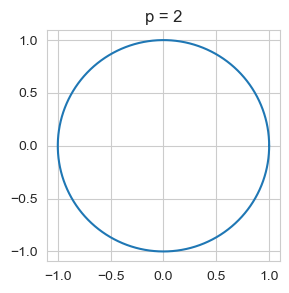

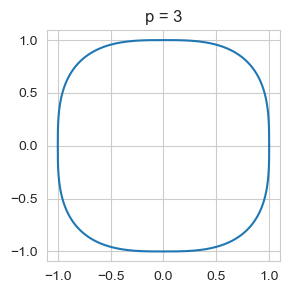

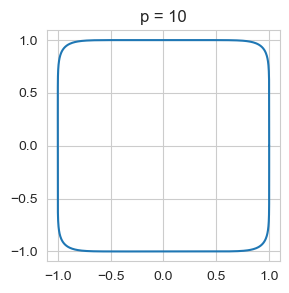

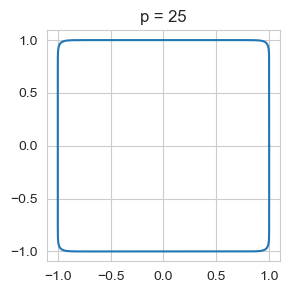

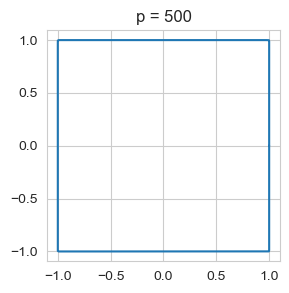

In [14]:
for p in [1, 1.25, 1.5, 1.75, 2, 3, 10, 25, 500]:

    x_list = []
    y_list = []
    for t in np.linspace(0, 2*np.pi, 1000):

        x = np.cos(t)
        y = np.sin(t)

        r = (abs(x)**p + abs(y)**p)**(1/p)

        x_list.append(x/r)
        y_list.append(y/r)
        
        
    plt.figure(figsize=(3, 3))
    plt.plot(x_list, y_list, '-')
    plt.xticks([-1, -0.5, 0 , 0.5, 1])
    plt.yticks([-1, -0.5, 0 , 0.5, 1])
    plt.axis('equal')
    plt.grid(True)
    plt.title('p = ' + str(p))
    plt.show()

Вглядитесь в эти фигуры повнимательнее. Каждая из них — это визуальный ответ на вопрос «что значит быть на расстоянии единица». И если вам кажется, что это всего лишь красивая абстракция, то позвольте вас заверить: когда ваша модель будет искать ближайших соседей, она будет опираться ровно на ту форму расстояния, которую вы ей зададите. Ромб, окружность или нечто среднее — выбор за вами. 

И выбор этот, поверьте, далеко не всегда очевиден.

### 2.2. Евклид против Манхэттена

В качестве пролога к драме возьмем три незамысловатые точки: O с координатами (0, 0), A — (1, 1) и B, скажем, (1.9, 0). 

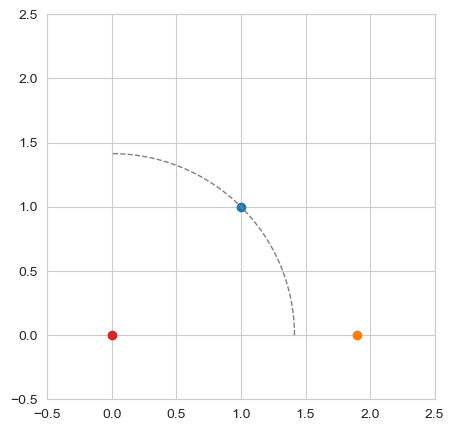

In [15]:
plt.figure(figsize=(5,5))
plt.xlim([-0.5, 2.5])
plt.ylim([-0.5, 2.5])

plt.plot(0, 0, 'o', color = 'C3')
plt.plot(1, 1, 'o', color = 'C0')
plt.plot(1.9, 0, 'o', color = 'C1')

circle_x = []
circle_y = []

for t in np.linspace(0, 3.1415926/2, 100):
    circle_x.append(2**0.5 * np.cos(t))
    circle_y.append(2**0.5 * np.sin(t))

plt.plot(circle_x, circle_y, '--', color='C7', lw=1)
    
plt.grid(True)
plt.show()

В евклидовой вселенной, где властвует расстояние по птичему полету, точка A, безусловно, ближе к началу координат, нежели B. Но стоит нам переключиться на прагматичную метрику Манхэттена, иерархия расстояний изящно выворачивается наизнанку: внезапно B оказывается ближе. Вот так, почти без усилий, мы сталкиваем две несоизмеримые перспективы на реальность.

Зафиксируем точку O, а A и B начнем смещать вправо с регулярным шагом 1.9. Возникнет целая серия точек: A₁ (1.9, 1), B₁ (3.8, 0), и так далее, ad infinitum. Договоримся о простой дихотомии: всё, что лежит на горизонтальной оси, отнесем к нулевому классу, а всё, что находится выше, на высоте y=1, — к единичному.

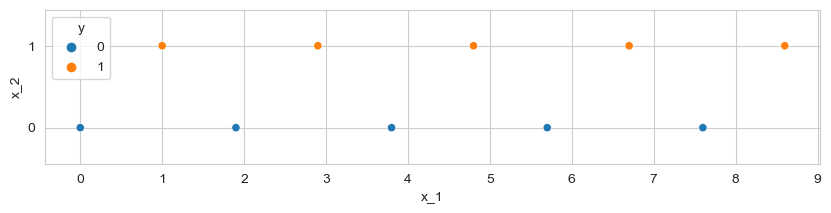

In [16]:
N=5

x_1_list = []

for i in range(N):
    x_1_list.append(i*1.9)
    
x_2 = np.zeros(N)

df_1 = pd.DataFrame(columns = ['x_1', 'x_2'])
df_1['x_1'] = x_1_list
df_1['x_2'] = x_2

x_1_list = []

for i in range(N):
    x_1_list.append(1 + i*1.9)
    
x_2 = np.ones(N) 

df_2 = pd.DataFrame(columns = ['x_1', 'x_2'])
df_2['x_1'] = x_1_list
df_2['x_2'] = x_2

df = pd.concat([df_1, df_2])
df['y'] = df['x_2'].astype(int)

plt.figure(figsize=(10, 2))
sns.scatterplot(data=df, x = 'x_1', y = 'x_2', hue = 'y')
plt.yticks(range(2))
plt.xticks(range(10))
plt.axis('equal')
plt.show()

Теперь — интерпретация, ради которой всё затевалось. 

Вообразите себя курьером с неподъемным рюкзаком, а наши две параллельные линии — это улицы, нулевая и первая. Ваше тело, скованное гравитацией и тяжестью бытия, прекрасно понимает: ближе всего тот адрес, что на вашей улице, а вовсе не тот, до которого вы гипотетически могли бы долететь, потому что летать вы не умеете. 

В этом месте, пожалуй, и кроется суть: метод ближайших соседей, натасканный на евклидову геометрию, будет настойчиво и даже маниакально — рекомендовать вам точку с соседней улицы. Приземленный Манхэттен — укажет соседа на той же линии.

Применим к сформированному таким образом набору данных метод ближайших соседей.

In [59]:
N=100

x_1_list = []

for i in range(N):
    x_1_list.append(i*1.9)
    
x_2 = np.zeros(N)

df_1 = pd.DataFrame(columns = ['x_1', 'x_2'])
df_1['x_1'] = x_1_list
df_1['x_2'] = x_2

x_1_list = []

for i in range(N):
    x_1_list.append(1 + i*1.9)
    
x_2 = np.ones(N) 

df_2 = pd.DataFrame(columns = ['x_1', 'x_2'])
df_2['x_1'] = x_1_list
df_2['x_2'] = x_2

df = pd.concat([df_1, df_2])
df['y'] = df['x_2'].astype(int)

X = df.drop(columns = ['y'])
y = df['y']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

knn = KNeighborsClassifier(metric='euclidean')
knn.fit(X_train, y_train)
y_pred_train = knn.predict(X_train)
y_pred_test = knn.predict(X_test)

EU_accuracy_train = accuracy_score(y_train, y_pred_train)
EU_accuracy_test = accuracy_score(y_test, y_pred_test)

knn = KNeighborsClassifier(metric='manhattan')
knn.fit(X_train, y_train)
y_pred_train = knn.predict(X_train)
y_pred_test = knn.predict(X_test)

MA_accuracy_train = accuracy_score(y_train, y_pred_train)
MA_accuracy_test = accuracy_score(y_test, y_pred_test)

print('EU_accuracy_train =', round(EU_accuracy_train, 4))
print('EU_accuracy_test  =', round(EU_accuracy_test, 4))
print('')
print('MA_accuracy_train =', round(MA_accuracy_train, 4))
print('MA_accuracy_test  =', round(MA_accuracy_test, 4))
print('')
print('Прирост скора = ', round(MA_accuracy_test - EU_accuracy_test, 4))

EU_accuracy_train = 0.6357
EU_accuracy_test  = 0.2167

MA_accuracy_train = 0.8857
MA_accuracy_test  = 0.65

Прирост скора =  0.4333


Вот, полюбуйтесь на этот красноречивый протокол позора. Евклидова метрика на обучающей выборке демонстрирует жалкие 0.64, а на тестовой и вовсе проваливается в бездну — 0.22, что, согласитесь, ~~немногим лучше~~ гораздо хуже случайного тыканья пальцем в небо. В то же время грубоватый, лишенный небесной геометрии Манхэттен выдает 0.89 на трейне и достойные, твердые 0.65 на тесте. Прирост скора на 43% — это не просто статистическая флуктуация, это приговор самой идее, будто расстояния в городе стоит мечтательно мерить по прямой. 

Резюмирую: Евклид проваливается с треском, достойным античной трагедии, а Манхэттен — рулит. 

### 2.3. Продолжение оптимистичного примера про металлопрокат

Мы с вами уже разбирали этот пример в первой главе с дотошностью, достойной лучшего применения, так что сейчас — просто перезагрузим данные, отряхнем их от пыли и продолжим ровно с того места, где остановились.

In [61]:
df = pd.read_csv('data/metal.csv')
df

,carbon_pct,manganese_pct,silicon_pct,sulfur_pct,phosphorus_pct,chromium_pct,nickel_pct,copper_pct,aluminum_pct,vanadium_pct,...,length_mm,temp_finish_rolling,temp_coiling,cooling_rate,tension_rolling,rolling_speed,elongation_pct,impact_strength_m40,yield_ratio,category
0,0.239705,0.202692,0.335947,0.007354,0.011625,-0.015151,0.034040,0.039825,0.042912,-0.004543,...,11123.637762,799.687163,578.737531,26.528643,26.764683,5.753519,18.212057,77.742237,0.715578,1
1,0.186847,1.136255,0.252721,0.015648,0.013660,0.111192,0.025215,0.015033,0.019995,0.019765,...,11272.258403,854.405896,638.033893,36.575280,33.311833,6.505862,28.413570,81.864543,0.716785,1
2,0.188297,0.914128,0.291510,0.011353,0.003447,0.122565,0.014973,0.011858,0.059439,0.009908,...,8652.204143,845.160618,628.529553,31.431585,16.416531,3.301266,22.379195,72.074793,0.727252,1
3,0.156488,1.055984,0.368557,0.009781,0.016166,0.162336,0.076119,0.019480,0.068086,0.005591,...,11657.234651,838.702334,563.843957,38.734102,22.746904,7.014372,23.526045,70.253183,0.600036,1
4,0.210759,1.038770,0.245114,0.007906,0.011508,0.085846,0.050128,0.010927,0.043558,-0.000133,...,10940.739775,869.394939,600.136570,41.111440,27.147025,9.640601,15.501607,57.191503,0.833878,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,0.161988,0.682743,0.226461,0.005880,0.023689,-0.036098,0.029234,0.027590,0.051258,0.012610,...,12821.390628,839.275215,510.305231,17.452111,24.298133,6.955740,14.179599,47.262108,0.707360,0
996,0.186954,1.113733,0.239429,0.015163,0.010188,-0.023060,0.000467,0.034956,0.032660,0.019351,...,11287.575100,846.725842,571.310027,32.914289,20.359341,5.660498,18.034580,62.077519,0.702616,0
997,0.169376,1.019220,0.211936,0.014974,0.007871,0.203252,0.035919,0.026054,0.037007,0.012107,...,9574.569848,818.023777,637.867447,18.148191,19.382904,6.641546,33.615347,85.193465,0.749081,1
998,0.172609,1.555615,0.305669,0.007548,0.010369,0.097637,0.033009,0.005801,0.043588,0.003958,...,13638.842414,870.940048,589.678216,16.107501,29.829158,5.083739,15.250094,49.979458,0.609822,0


Манхэттен и Евклид, как вы, надеюсь, помните, — всего лишь частные, почти банальные случаи расстояния Минковского, где за всё отвечает один-единственный параметр p, этакий ползунок между геометриями. Напрашивается естественный вопрос: а что, если нам перестать выбирать между двумя крайностями и попросту подкрутить этот p так, чтобы accuracy взлетела повыше? 

Пробуем:

-------------------
Индикатор прогресса
-------------------
1.0
1.25
1.5
1.75
2.0
2.25
2.5
2.75
-------------------


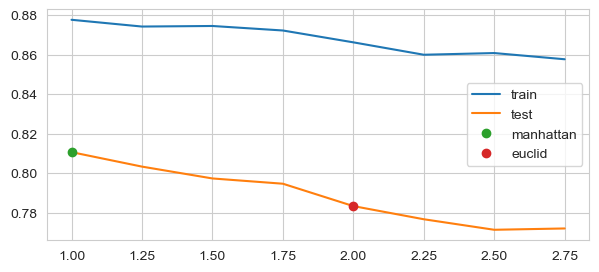

Скор Манхэттена: 0.8107
Скор Евклида: 0.7833
Прирост скора: 0.0273


In [62]:
X = df.drop(columns = ['category'])
y = df['category']

# X_scaled = X # Это без нормализации

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

p_list = np.arange(1, 3, 0.25)

horisontal_ax = []

Accuracy_train_list = []
Accuracy_test_list = []

p_Ma = 0
Ma = 0
p_Eu = 0
Eu = 0

print('-------------------')
print('Индикатор прогресса')
print('-------------------')

for p in p_list:
    print(p) 

    horisontal_ax.append(p)

    accuracy_train_list = []
    accuracy_test_list = []

    for seed in range(5):

        X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=seed)

        model = KNeighborsClassifier(metric='minkowski', p=p)
        model.fit(X_train, y_train)

        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)

        accuracy_train = accuracy_score(y_train, y_train_pred)
        accuracy_test = accuracy_score(y_test, y_test_pred)

        accuracy_train_list.append(accuracy_train)
        accuracy_test_list.append(accuracy_test)

    Accuracy_train_list.append(np.array(accuracy_train_list).mean())
    Accuracy_test_list.append(np.array(accuracy_test_list).mean())

    if round(p, 1) == 1.0:
        
        Ma = np.mean(np.array(accuracy_test_list).mean())
        p_Ma = p
    
    if round(p, 1) == 2.0:
        Eu = np.mean(np.array(accuracy_test_list).mean())
        p_Eu = p
        
print('-------------------')

plt.figure(figsize=(7, 3))
plt.grid(True)
plt.plot(horisontal_ax, Accuracy_train_list, label = 'train')
plt.plot(horisontal_ax, Accuracy_test_list, label = 'test')
plt.plot(p_Ma, Ma, 'o', label = 'manhattan')
plt.plot(p_Eu, Eu, 'o', label='euclid')
plt.legend()
plt.show()

print('Скор Манхэттена:', round(Ma, 4))
print('Скор Евклида:', round(Eu, 4))
print('Прирост скора:', round(Ma-Eu, 4))

И вот он, момент истины, пусть и лишенный драматических спецэффектов. Да, такое значение p существует (правда, он привело нас к одной из крайностей, так как это значение p=1), и да, Манхэттен вновь обходит Евклида — без фанфар, но уверенно, с преимуществом примерно в два с половиной процента. Мы, разумеется, люди негордые и прекрасно понимаем, что в промышленных масштабах и эти жалкие 0.02 — прирост, за который иной data scientist продал бы душу. Скромно, почти буднично, но результат есть, и он наш.

Дальше — обучаем модель в манхэттенской метрике и опять подбираем оптимальное число соседей:

-------------------
Индикатор прогресса
-------------------
k = 5
k = 30
k = 55
k = 80
k = 105
k = 130
k = 155
k = 180
k = 205
k = 230
k = 255
k = 280
k = 305
k = 330
k = 355
k = 380
k = 405
k = 430
k = 455
k = 480
-------------------


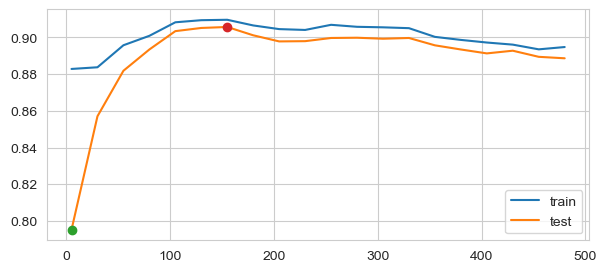

Дефолтный скор: 0.7952
Максимальный скор: 0.9057 при k = 155
Прирост скора: 0.1105


In [63]:
X = df.drop(columns = ['category'])
y = df['category']

scaler = StandardScaler()
X = scaler.fit_transform(X)

horisontal_ax = []

Accuracy_train_list = []
Accuracy_test_list = []

print('-------------------')
print('Индикатор прогресса')
print('-------------------')

for k in range(5, round(50*len(X)/100), 25):
    

    print('k =', k)
    horisontal_ax.append(k)

    accuracy_train_list = []
    accuracy_test_list = []

    for seed in range(25):

        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=seed)

        model = KNeighborsClassifier(k, metric='manhattan')
        model.fit(X_train, y_train)

        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)

        accuracy_train = accuracy_score(y_train, y_train_pred)
        accuracy_test = accuracy_score(y_test, y_test_pred)

        accuracy_train_list.append(accuracy_train)
        accuracy_test_list.append(accuracy_test)

    Accuracy_train_list.append(np.array(accuracy_train_list).mean())
    Accuracy_test_list.append(np.array(accuracy_test_list).mean())
    
print('-------------------')

max_score_index = np.argmax(np.array(Accuracy_test_list))

plt.figure(figsize=(7, 3))
plt.grid(True)
plt.plot(horisontal_ax, Accuracy_train_list, label = 'train')
plt.plot(horisontal_ax, Accuracy_test_list, label = 'test')
plt.plot(horisontal_ax[0], Accuracy_test_list[0], 'o')
plt.plot(horisontal_ax[max_score_index], Accuracy_test_list[max_score_index], 'o')
plt.legend()
plt.show()

print('Дефолтный скор:', round(np.array(Accuracy_test_list)[0], 4))
print('Максимальный скор:', round(np.array(Accuracy_test_list).max(), 4), 'при k =', max_score_index*25 + 5)
print('Прирост скора:', (np.array(Accuracy_test_list).max() - np.array(Accuracy_test_list)[0]).round(4))

Вот. Картина, приятная глазу.

Заметьте: мы пробили психологический барьер 0.9, даже не притрагиваясь к очистке данных от шумовых признаков, просто сменив геометрию пространства, в котором обитает наша модель. Евклидова окружность уступила место манхэттенской угловатости, и результат оказался вполне достойным.

## § 3. Параметр `weights`

Что ж, амигос, приготовьтесь к довольно элегантному трюку  метода k ближайших соседей. 

До сих пор мы позволяли всем соседям выступать с одинаковой силой — своего рода демократия, где голос каждого тракториста из глубинки весит ровно столько же, сколько голос академика, живущего в сталинской высотке. Параметр `weights` — это наш способ навести в этом митинге порядок: теперь одни будут менее заметны, чем другие, и, как вы увидите, этот изящный прием  порой спасает модель от вопиющей несправедливости реального мира. 

### 3.1. Значения `uniform` и `distance`

Вопреки распространённому заблуждению, алгоритм kNN не раздаёт окончательные классы направо и налево — он куда осторожнее и возвращает вероятность принадлежности объекта к каждому из классов, оценённую прямым голосованием соседей. 

Взгляните на иллюстрацию ниже: при k=3 перед нами серая точка x₀ в окружении двух синих и одной жёлтой — классическая ситуация, в которой даже самый рассеянный наблюдатель уверенно скажет, что перед ним синий экземпляр. Механика этого умозаключения до неприличия проста: численное большинство побеждает, и точка принимает окраску большинства — вот, собственно, и вся идея режима `uniform`.

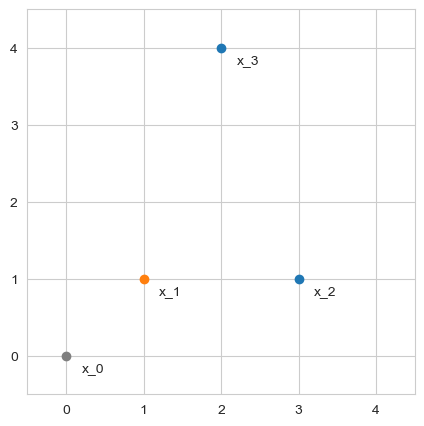

In [208]:
plt.figure(figsize=(5,5))
plt.xlim([-0.5, 4.5])
plt.ylim([-0.5, 4.5])

plt.plot(0, 0, 'o', color = 'C7')
plt.text(0.2, -0.2, 'x_0')

plt.plot(1, 1, 'o', color = 'C1')
plt.text(1.2, 0.8, 'x_1')

plt.plot(3, 1, 'o', color = 'C0')
plt.text(3.2, 0.8, 'x_2')

plt.plot(2, 4, 'o', color = 'C0')
plt.text(2.2, 3.8, 'x_3')

plt.grid(True)
plt.show()

Ответ очевиден. Из трех ближайших точек две синие и одна желтая. Синих больше, поэтому и серая точка тоже синяя. При прямом голосовании все три голоса имеют равный вес — по одной третьей, и именно из этих долей складываются итоговые вероятности: две трети за синий, одна треть за жёлтый. 

Теперь усложним модель: рассмотрим плоскость как метрическое пространство, и для простоты вычислений выберем манхэттенскую метрику, избавляющую нас от необходимости извлекать квадратные корни. В этой метрике:

- точка x_1 удалена от x_0 на расстояние |x_1 - x_0| = 2, 
- x_2 — на расстояние |x_2 - x_0| = 4, 
- а x_3  — на расстояние |x_3 - x_0| = 6.

Веса голосов назначим обратно пропорциональными этим расстояниям: 

- w(x_1) = 1/2, 
- w(x_2) = 1/4, 
- w(x_3) = 1/6. 

— так мы переходим от равноправного голосования к взвешенному, где близость к исследуемой точке напрямую определяет значимость голоса.

Однако найденные значения — это ещё не веса в строгом смысле слова, а лишь их сырые заготовки, поскольку настоящие весовые коэффициенты должны в сумме давать единицу. У нас же сумма равна 11/12, что, согласитесь, до единицы не дотягивает. Чтобы исправить эту оплошность, достаточно нормировать каждый вес, разделив его на общую сумму, — и тогда мы получаем корректные значения: 

- w(x_1) = 1/2·12/11 = 6/11, 
- w(x_2) = 1/4·12/11 = 3/11, 
- w(x_3) = 1/6·12/11 = 2/11.

Теперь единственный голос в пользу желтого цвета перевешивает два голоса в пользу синего, потому что

6/11 > 3/11 + 2/11 = 5/11.

Вывод — серая точка x_0 на самом деле является желтой.

Так мы наблюдаем принцип взвешенного голосования — ближайшие соседи говорят громче, а далёкие шепчут, и именно эту логику реализует параметр `weights`: `uniform` даёт каждому голосу равную силу, тогда как `distance` распределяет влияние пропорционально близости к исследуемой точке.

### 3.2. Связь `n_neighbors` и `weights`

,insulation_resistance,capacitance_imbalance,cable_lot_assignment
0,3745.958629,1.603955,1
1,6446.631845,2.741794,0
2,2156.124547,0.567434,0
3,4015.926669,1.073053,1
4,3152.613060,1.833179,0
...,...,...,...
1995,3525.561452,1.212553,0
1996,3895.847627,1.162269,1
1997,4830.170196,0.636936,0
1998,3370.717020,1.316404,1


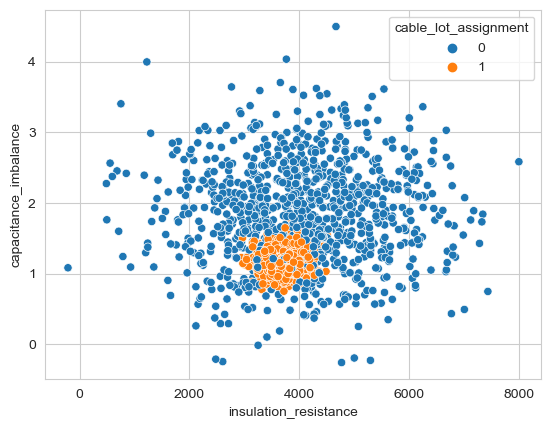

In [3]:
df = pd.read_csv('data/cable.csv')
display(df)

sns.scatterplot(data = df, x = 'insulation_resistance', y = 'capacitance_imbalance', hue = 'cable_lot_assignment')
plt.show()

#### Контекст 
    
Кабельный завод выпускает бухты кабеля одной марки. Но из-за вариаций в скорости наложения изоляции сопротивление изоляции варьируется от бухты к бухте. Два заказчика ждут по 50% партии: один для подводной прокладки (нужно повышенное качество), другой для сухопутной сети (стандартное качество). 

#### Предикторы

- insulation_resistance — сопротивление изоляции (в МОм·км; основная масса бухт имеет широкий разброс значений, но часть бухт, изготовленных на определённой линии, стабильно попадает в узкий диапазон из-за более точной дозировки сшивающего агента).
- capacitance_imbalance — дисбаланс ёмкости между жилами (в пФ/м; флуктуирует в широком диапазоне в норме, но сужается для кабелей с более однородной геометрией).


#### Таргет

- cable_lot_assignment — назначение бухты в партию для конкретного заказчика (0: для сухопутной сети, 1: для подводной прокладки).

#### Бизнес-задача 

Автоматическая сортировка бухт в две равные партии с гарантией, что одна партия систематически имеет лучшие электрические характеристики. Неверное распределение приведёт к тому, что подводный заказчик получит кабель с заниженным сопротивлением, что приведёт к аварии при прокладке и многомиллионным убыткам.

#### Равноправное и взвешенное голосование с большим числом ближайших соседей

Проведём уже знакомый — и, смею надеяться, ставший привычным — ритуал: многократные случайные разбиения на обучающую и тестовую выборки с последующим накоплением и усреднением accuracy. На этот раз двигать будем лишь один переключатель — параметр `weights`, сравнивая равноправное голосование со взвешенным на этих разбиениях.

In [7]:
np.random.seed(42)

X = df.drop(columns = ['cable_lot_assignment'])
y = df['cable_lot_assignment']

score_train_list = []
score_test_list = []

for seed in range(25):

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=seed)

    model = KNeighborsClassifier(n_neighbors=400, weights='uniform')
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    score_train = accuracy_score(y_train, y_train_pred)
    score_test = accuracy_score(y_test, y_test_pred)

    score_train_list.append(score_train)
    score_test_list.append(score_test)
    
uniform = score_test_list
    
uni_accuracy_train = round(np.array(score_train_list).mean(), 4)
uni_accuracy_test = round(np.array(score_test_list).mean(), 4)

print('uniform')
print('accuracy_train =', uni_accuracy_train)
print('accuracy_test =', uni_accuracy_test)
print('accuracy_std =', round(np.array(uniform).std(), 4))
print('')

score_train_list = []
score_test_list = []

for seed in range(25):

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=seed)

    model = KNeighborsClassifier(n_neighbors=400, weights='distance')
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    score_train = accuracy_score(y_train, y_train_pred)
    score_test = accuracy_score(y_test, y_test_pred)

    score_train_list.append(score_train)
    score_test_list.append(score_test)
    
distance = score_test_list

dist_accuracy_train = round(np.array(score_train_list).mean(), 4)
dist_accuracy_test = round(np.array(score_test_list).mean(), 4)

print('distance')
print('accuracy_train =', dist_accuracy_train)
print('accuracy_test =', dist_accuracy_test)
print('accuracy_std =', round(np.array(distance).std(), 4))
print('')

print('Прогресс')
print('delta_accuracy_test =', round(dist_accuracy_test - uni_accuracy_test, 4))

uniform
accuracy_train = 0.7834
accuracy_test = 0.7803
accuracy_std = 0.0236

distance
accuracy_train = 1.0
accuracy_test = 0.8185
accuracy_std = 0.0134

Прогресс
delta_accuracy_test = 0.0382


Что ж, прирост действительно есть — скромный, но статистически различимый, и в нашем деле пренебрегать даже такими улучшениями было бы неосмотрительно. Взвешенное голосование чуть лучше обобщается на тестовую выборку и даёт заметно меньший разброс accuracy, что уже само по себе приятно.

#### То же самое с дефолтным `n_neighbors`

Теперь поступим несколько провокационнее: вернём равноправному голосованию дефолтное значение `n_neighbors=5`, а взвешенное оставим при четырёхстах. 

In [16]:
score_train_list = []
score_test_list = []

for seed in range(25):

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=seed)

    model = KNeighborsClassifier()
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    score_train = accuracy_score(y_train, y_train_pred)
    score_test = accuracy_score(y_test, y_test_pred)

    score_train_list.append(score_train)
    score_test_list.append(score_test)
    
uniform = score_test_list
    
uni_accuracy_train = round(np.array(score_train_list).mean(), 4)
uni_accuracy_test = round(np.array(score_test_list).mean(), 4)

print('uniform')
print('accuracy_train =', uni_accuracy_train)
print('accuracy_test =', uni_accuracy_test)
print('accuracy_std =', round(np.array(uniform).std(), 4))
print('')

score_train_list = []
score_test_list = []

for seed in range(25):

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=seed)

    model = KNeighborsClassifier(n_neighbors=400, weights='distance')
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    score_train = accuracy_score(y_train, y_train_pred)
    score_test = accuracy_score(y_test, y_test_pred)

    score_train_list.append(score_train)
    score_test_list.append(score_test)
    
distance = score_test_list
    
dist_accuracy_train = round(np.array(score_train_list).mean(), 4)
dist_accuracy_test = round(np.array(score_test_list).mean(), 4)

print('distance')
print('accuracy_train =', dist_accuracy_train)
print('accuracy_test =', dist_accuracy_test)
print('accuracy_std =', round(np.array(distance).std(), 4))
print('')

print('Прогресс')
print('delta_accuracy_test =', round(dist_accuracy_test - uni_accuracy_test, 4))


uniform
accuracy_train = 0.8563
accuracy_test = 0.8035
accuracy_std = 0.0108

distance
accuracy_train = 1.0
accuracy_test = 0.8185
accuracy_std = 0.0134

Прогресс
delta_accuracy_test = 0.015


И вот он, отрезвляющий результат: разница в `accuracy_test` съёжилась до полутора процентов. Это, мягко говоря, не прорыв.

Взвешенное голосование демонстрирует свои преимущества лишь при большом числе соседей, когда равноправное уже захлебывается в шуме. Но позвольте спросить: а что, собственно, мешает нам просто уменьшить `n_neighbors`? Ведь` weights='distance`', по сути, делает то же самое, только вместо жёсткого отсечения далёких точек он их плавно заглушает — мягче, деликатнее, и куда менее радикально. А радикальный подход с малым числом соседей попросту выбрасывает лишнее и оставляет лишь тех, кто действительно рядом. 

`n_neighbors` — это настраиваемый параметр, и мы не просто вольны его подбирать: мы обязаны найти такое значение, при котором модель начинает вести себя прилично. Вот мы его и нашли. Это значение — дефолтое `n_neighbors=5`.

#### Ситематическое смещение тестовой выборки

Представим ситуацию, которая на практике встречается куда чаще, чем хотелось бы. У нас есть размеченные данные по кабелям — тот самый датасет, который мы загружаем из CSV. Но обратите внимание: размечены они были, мягко говоря, давно — год, а то и два назад. А партии кабеля нам приходится классифицировать каждый божий день, и единственное, на что мы можем опереться, — эти самые устаревшие, но бесценные образцы. Ибо разметка, как вы понимаете, удовольствие дорогое, и обновлять её по каждому чиху никто не станет.

И вот тут возникает вопрос, который мои коллеги почему-то предпочитают обходить стороной: а кто вам сказал, что сегодняшняя партия кабеля будет иметь то же распределение, что и эталонные размеченные данные? Правильно — никто. Я, во всяком случае, такого не утверждал. Вполне реальна ситуация, при которой измерительный прибор, снимающий показания для первого предиктора, слегка люфтит. Пусть, для простоты, этот люфт проявляется лишь на одной линии — той самой, что производит кабели для подводной прокладки.

Чтобы смоделировать этот эффект, нам придётся пересмотреть саму процедуру построения обучающей и тестовой выборок. Мы, признаться, привыкли к тому, что разбиение делается методом `train_test_split` из библиотеки Scikit-learn, и это удобно. Но в этом методе зашито негласное, но очень важное допущение: данные, на которых будет осуществляться прогноз, происходят из того же распределения, что и данные, на которых модель обучалась. Красивое, но, увы, не всегда выполнимое предположение.

В нашем случае оно заведомо нарушено. Прогноз придётся делать на данных, смещённых относительно обучающих. Поэтому поступим так: обучающей выборкой будем считать весь наш размеченный датасет целиком, а в качестве тестовой возьмём тот же самый датасет, но с жёлтым облаком, слегка сдвинутым по горизонтали. Это и есть имитация люфта измерений на линии, производящей подводные кабели. Просто, наглядно и, что немаловажно, вполне реалистично.

#### И снова: равноправное и взвешенное голосование с большим числом ближайших соседей

Возьмём 400 соседей — число, которое ранее не давало особого повода для восторга, — и применим оба типа взвешивания к нашей новой смещённой тестовой выборке. В остальном процедура остаётся той же: многократные разбиения, накопление accuracy, усреднение.

In [19]:
np.random.seed(42)

df = pd.read_csv('data/cable.csv')
df = df.rename(columns = {'insulation_resistance': 'x1', 'capacitance_imbalance':'x2', 'cable_lot_assignment': 'y'})

# Обучающий датафрейм
X_train = df.drop(columns = ['y'])
y_train =df['y']

score_train_list = []
score_test_list = []

for seed in range(25):
    
    s = np.random.normal(0, 2, 1)[0] 
    
    def shift(row):
        if row['y'] == 1:
            return row['x1'] + s
        else:
            return row['x1']
    # Датафрейм для прогноза (тестовый), получается из обучающего параллельным переносом.
    df_test = df.copy()
    df_test['x1'] = df_test.apply(shift, axis=1)
                               
    X_test = df_test.drop(columns = ['y'])
    y_test =df_test['y']
    
    # Соседей много, голоса равноправные
    model = KNeighborsClassifier(n_neighbors = 400, weights='uniform')
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    score_train = accuracy_score(y_train, y_train_pred)
    score_test = accuracy_score(y_test, y_test_pred)

    score_train_list.append(score_train)
    score_test_list.append(score_test)
    
uniform = score_test_list
    
uni_accuracy_train = round(np.array(score_train_list).mean(), 4)
uni_accuracy_test = round(np.array(score_test_list).mean(), 4)

# Характеристики прогноза
print('uniform')
print('accuracy_train =', uni_accuracy_train)
print('accuracy_test =', uni_accuracy_test)
print('accuracy_std =', round(np.array(uniform).std(), 4))
print('')

# Все заново для дургого голосования
score_train_list = []
score_test_list = []

for seed in range(25):
    
    s = np.random.normal(0, 2, 1)[0] 
    
    def shift(row):
        if row['y'] == 1:
            return row['x1'] + s
        else:
            return row['x1']
        
    # Датафрейм для прогноза (тестовый), получается из обучающего параллельным переносом.
    df_test = df.copy()
    df_test['x1'] = df_test.apply(shift, axis=1)
                               
    X_test = df_test.drop(columns = ['y'])
    y_test =df_test['y']
    
    # Соседей много, голосование взвешенное
    model = KNeighborsClassifier(n_neighbors = 400, weights='distance')
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    score_train = accuracy_score(y_train, y_train_pred)
    score_test = accuracy_score(y_test, y_test_pred)

    score_train_list.append(score_train)
    score_test_list.append(score_test)
    
distance = score_test_list
    
dist_accuracy_train = round(np.array(score_train_list).mean(), 4)
dist_accuracy_test = round(np.array(score_test_list).mean(), 4)

# Характеристики прогоноза
print('distance')
print('accuracy_train =', dist_accuracy_train)
print('accuracy_test =', dist_accuracy_test)
print('accuracy_std =', round(np.array(distance).std(), 4))
print('')

print('Прогресс')
print('delta_accuracy_test =', round(dist_accuracy_test - uni_accuracy_test, 4))

uniform
accuracy_train = 0.805
accuracy_test = 0.8048
accuracy_std = 0.0002

distance
accuracy_train = 1.0
accuracy_test = 0.9749
accuracy_std = 0.0116

Прогресс
delta_accuracy_test = 0.1701


А вот это уже интересно. Семнадцать процентов прироста на тесте — не та цифра, которую можно списать на статистическую погрешность, и выглядит она куда убедительнее жалких полутора процентов из предыдущего эксперимента. Похоже, мы нащупали сценарий, в котором взвешенное голосование действительно оправдывает своё существование, причём оправдывает с размахом.

#### И снова: дефолтное значение `n_neighbors`

Теперь поступим так же, как и прежде, — противопоставим классический kNN с дефолтными пятью соседями взвешенной версии с четырьмя сотнями, но уже на смещённых тестовых данных. Вопрос прежний: устоит ли репутация простого равноправного голосования?

In [20]:
np.random.seed(42)

df = pd.read_csv('data/cable.csv')
df = df.rename(columns = {'insulation_resistance': 'x1', 'capacitance_imbalance':'x2', 'cable_lot_assignment': 'y'})

X_train = df.drop(columns = ['y'])
y_train =df['y']

score_train_list = []
score_test_list = []

for seed in range(25):
    
    s = np.random.normal(0, 2, 1)[0] 
    
    def shift(row):
        if row['y'] == 1:
            return row['x1'] + s
        else:
            return row['x1']
        
    # Датафрейм для прогноза (тестовый), получается из обучающего параллельным переносом.
    df_test = df.copy()
    df_test['x1'] = df_test.apply(shift, axis=1)
                               
    X_test = df_test.drop(columns = ['y'])
    y_test =df_test['y']
    
    # Мало соседей, голоса равноправные
    model = KNeighborsClassifier()
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    score_train = accuracy_score(y_train, y_train_pred)
    score_test = accuracy_score(y_test, y_test_pred)

    score_train_list.append(score_train)
    score_test_list.append(score_test)
    
# Набор accuracy на test'е на всех запусках
uniform = score_test_list
    
uni_accuracy_train = round(np.array(score_train_list).mean(), 4)
uni_accuracy_test = round(np.array(score_test_list).mean(), 4)

# Характеристики прогноза
print('uniform')
print('accuracy_train =', uni_accuracy_train)
print('accuracy_test =', uni_accuracy_test)
print('accuracy_std =', round(np.array(uniform).std(), 4))
print('')

# Все заново для дургого голосования
score_train_list = []
score_test_list = []

for seed in range(25):
    
    s = np.random.normal(0, 2, 1)[0] 
    
    def shift(row):
        if row['y'] == 1:
            return row['x1'] + s
        else:
            return row['x1']
    
    df_test = df.copy()
    df_test['x1'] = df_test.apply(shift, axis=1)
                               
    X_test = df_test.drop(columns = ['y'])
    y_test =df_test['y']
    
    # Соседей много, голосование взвешенное
    model = KNeighborsClassifier(n_neighbors = 400, weights='distance')
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    score_train = accuracy_score(y_train, y_train_pred)
    score_test = accuracy_score(y_test, y_test_pred)

    score_train_list.append(score_train)
    score_test_list.append(score_test)
    
distance = score_test_list
    
dist_accuracy_train = round(np.array(score_train_list).mean(), 4)
dist_accuracy_test = round(np.array(score_test_list).mean(), 4)

# Характеристики прогоноза
print('distance')
print('accuracy_train =', dist_accuracy_train)
print('accuracy_test =', dist_accuracy_test)
print('accuracy_std =', round(np.array(distance).std(), 4))
print('')

print('Прогресс')
print('delta_accuracy_test =', round(dist_accuracy_test - uni_accuracy_test, 4))

uniform
accuracy_train = 0.8605
accuracy_test = 0.8565
accuracy_std = 0.0062

distance
accuracy_train = 1.0
accuracy_test = 0.9749
accuracy_std = 0.0116

Прогресс
delta_accuracy_test = 0.1184


Одиннадцать — почти двенадцать — процентов прироста, конечно, поскромнее семнадцати, но всё равно результат, заслуживающий внимания. Согласитесь: терять почти двенадцать процентов accuracy только из-за того, что вы поленились включить учёт расстояний, — это непозволительная роскошь для инженера, который отвечает за подводные кабели.

#### Выводы

Итак, зафиксируем. 

Мы с вами только что — возможно, сами того не до конца осознавая — вскрыли методологический пласт куда более глубокий, чем банальная победа одного гиперпараметра над другим. Смотрите: весь фокус здесь в системном сдвиге. Это не просто академический каприз, это принципиальный модус существования реальных данных. Если бы каждая точка класса 1 совершала независимое броуновское движение, мы бы имели дело с банальным увеличением дисперсии. Облако размывалось бы, шум рос, и любой метод рано или поздно захлебнулся бы, просто в силу роста энтропии. 

Но наш эксперимент имитирует нечто иное — и, замечу, куда более реалистичное. Мы симулируем физический процесс, в котором производственная линия «уплывает» вся, целиком, как единый организм. Это когерентный дрейф. И вот тут-то, на этом контрапункте между хаотическим шумом и когерентным сдвигом, `distance` и показывает своё истинное благородство. Он не просто «чувствует» близость — он, по сути, восстанавливает локальную структуру там, где глобальная картина уже полностью искажена.

Обратите внимание на элегантность постановки эксперимента. Здесь нет и тени того методологического греха, который мы, увы, часто наблюдаем в студенческих работах: мы не подглядываем в тест. Это не просто формальность, это — честность исследователя. Обучающая выборка зафиксирована раз и навсегда — это наш неприкосновенный золотой стандарт, наши старые, размеченные с кровью и потом данные. А тестовую выборку мы конструируем сами, вручную задавая тот самый известный тип дрейфа, имитируя будущие, еще не виданные партии. Мы, позволю себе метафору, не гадаем на кофейной гуще, а строим аэродинамическую трубу.

И вот тут мы подходим к кульминации методологической мысли. Понимаете, это ведь куда честнее и, простите за прямоту, куда умнее стандартного `train_test_split`. Что делает случайное разбиение? Оно молчаливо — и часто ошибочно — предполагает стационарность мира. Оно говорит нам: «Завтра будет статистически неотличимо от вчера». Но мы-то с вами знаем, что это не так. В реальных production-условиях мир стационарен лишь в мечтах менеджмента. У нас же есть роскошь — или, если угодно, суровая необходимость — знать характер дрейфа заранее. И мы адаптируем процедуру валидации под эту реальность, а не подгоняем реальность под учебник.

И, наконец, финальный аккорд. 

Я полагаю, мы с вами только что, почти случайно, наткнулись на изящный частный случай принципа робастного оценивания через избыточное сглаживание с весами, зависящими от расстояния. Это звучит как заклинание, но суть проста. Distance-based weighting в данном контексте выступает не просто как «умная» версия kNN, а как своего рода защитный механизм. Он перестает быть просто эвристикой близости и превращается в щит. И это работает именно тогда — и это критически важно, — когда adversarial perturbations, соперничающие возмущения, вносимые дрейфом, затрагивают не всё пространство признаков, а лишь строго локализованный его сектор. Класс 1 уплыл, класс 0 остался. Тогда взвешенные голоса спасают ситуацию.

Вот так, амигос. Мы начинали с двух строчек в sklearn, а закончили философией устойчивости в нестационарных средах. И знаете, ради таких моментов и стоит заниматься наукой.

### 3.3. Параметр `weights` и высокие размерности

В высоких размерностях выстраивать веса обратно пропорционально расстояниям бессмысленно. Причина проста: расстояния между точками выравниваются (этот эффект мы разбирали в §1), и ранжирование по близости перестает нести информацию. По сути, мы присваиваем больший вес соседу лишь потому, что он случайно оказался чуть ближе, — а разница между «ближе» и «дальше» в многомерном пространстве статистически неотличима от шума. Надеяться на distance при 20 или 30 предикторах — значит уповать на то, что монетка запомнит ваш выбор.

Единственным инструментом регуляризации в таких пространствах остается число соседей k — этот эффект мы также рассматривали ранее. Варьируя k, мы по-прежнему контролируем сложность модели и уровень сглаживания. А вот взвешенное голосование, увы, превращается в декоративный элемент: оно элегантно выглядит на плоскости, где расстояния осмысленны, но в многомерном пространстве не дает ничего, кроме ложного ощущения контроля.

## Домашнее задание

>#### Задание 1
Прочитайте файл `weld.csv`.

#### Контекст

Завод металлоконструкций использует два штатных технологических режима сварки: режим A — автоматическая сварка (высокая скорость, высокая производительность), режим B — ручная сварка (высокое качество, для ответственных узлов). По косвенным метрикам нужно определить, каким режимом был выполнен шов, чтобы корректно назначить контроль и срок службы конструкции.


#### Предикторы

- weld_penetration_depth — глубина проплавления, мм,
- seam_width— ширина шва, мм,
- seam_height — высота шва, мм,
- welding_current — ток сварки, А,
- welding_voltage — напряжение сварки, В,
- welding_speed — скорость сварки, мм/с,
- wire_feed_speed — скорость подачи проволоки, м/мин,
- wire_diameter — диаметр проволоки, мм,
- gas_flow_rate — расход защитного газа, л/мин,
- gas_pressure — давление газа, бар,
- gas_purity — чистота газа, %,
- torch_angle — угол наклона горелки, °,
- torch_distance — расстояние горелки, мм,
- preheat_temperature — температура предварительного нагрева, °C,
- base_metal_thickness — толщина основного металла, мм,
- base_metal_temp — температура металла, °C,
- ambient_temp — температура в цехе, °C,
- air_humidity — влажность, %,
- wind_speed — скорость ветра, м/с,
- plate_cleanliness — чистота пластины, балл,
- surface_oxide — оксидная плёнка, %,
- joint_gap — зазор соединения, мм,
- joint_alignment — соосность соединения, мм,
- tack_weld_quality — качество прихватки, балл,
- fixture_pressure — прижим приспособления, Н,
- fixture_accuracy — точность приспособления, мм,
- robot_position — позиция робота, мм,
- robot_speed_dev — отклонение скорости робота, %,
- robot_vibration — вибрация робота, мм/с,
- controller_temp — температура контроллера, °C,
- cooling_water_temp — температура охлаждающей воды, °C,
- power_fluctuation — колебания напряжения, %,
- induction_noise — индукционные помехи, мВ,
- electrode_condition — состояние электрода, балл,
- contact_tip_wear — износ контактного наконечника, %,
- nozzle_soiling — загрязнение сопла, %,
- weld_metal_type — тип присадочного металла, №,
- batch_metal_quality — качество партии металла, балл,
- operator_skill — квалификация оператора, балл.

#### Таргет

- welding_mode — 0: автоматическая сварка, 1: ручная сварка.

#### Бизнес-задача

Ошибка классификации ведёт к неправильному назначению контроля: ручной шов будет принят как автоматический, и в ответственных узлах может произойти разрушение. Точная классификация гарантирует корректный контроль и снижает риски аварий на 40%.

>#### Задание 2
Обучите baseline-модель бинарной классификации.

In [21]:
# Код

>#### Задание 3
Подберите оптимальное число ближайших соседей. Заметно ли вырос скор?

In [22]:
# Код.

>#### Задание 4
Проведите нормализацию данных и еще раз подберите оптимальное число ближайших соседей. Заметно ли вырос скор? А по сравнению с baseline-моделью?

In [23]:
# Код

>#### Задание 5
Подберите оптимальное значение показателя метрики Минковского, после чего, уже в этой метрике — еще раз подберите оптимальное число ближайших соседей. Заметно  ли вырос скор? А по сравнению с baseline-моделью?

In [25]:
# Код

>#### Задание 6
Определите сигнальные предикторы. Удалите шумовые предикторы и проведите регуляризаци классификатора на сигнальных. Сравните результаты с полученными выше.

In [ ]:
# Код